In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
wkdir = '/home/jing/Phd_project/project_UCD_blca/blca_DATA/blca_DATA_finalisation'

In [3]:
stvs = pd.read_excel(os.path.join(wkdir,'ALL_DATA_2020.xlsx'),sheet_name='STV',index_col='Genes')

In [4]:
stvsDPD_immuno

,DPD_BL,DPD_onc,DPD_risk,DPD_T2,DPD_Ta,DPD_immuno
Genes,,,,,,
AARS,0.0,0.078480,0.000000,0.0,0.0,0.0
ABCB6,0.0,0.027123,-0.153918,0.0,0.0,0.0
ABCC5,0.0,0.002120,0.000000,0.0,0.0,0.0
ABCF1,0.0,-0.028956,-0.026418,0.0,0.0,0.0
ABCF3,0.0,0.036668,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...
ZNF395,0.0,0.000000,0.000000,0.0,0.0,0.0
ZNF451,0.0,0.013401,0.000000,0.0,0.0,0.0
ZNF586,0.0,0.000000,0.006341,0.0,0.0,0.0


In [5]:
stv_a0_df = pd.read_csv(os.path.join(wkdir,'survival_coeffs_glmnet_L1000_a_0_0.csv'),index_col=0) 

In [6]:
stv_a0 = stv_a0_df.loc[stv_a0_df.index.intersection(stvs.index), :]

In [7]:
stv_a0

,x
ABCB6,0.014414
ABCC5,-0.005542
ABCF1,-0.032539
ABCF3,-0.004503
ABHD4,0.012433
...,...
ZNF395,0.009050
ZNF451,-0.008866
ZNF586,0.035861
ZNF589,0.016951


In [8]:
norm = np.sqrt((stv_a0 ** 2).sum())
raw_normalized = stv_a0 / norm

assert np.isclose((raw_normalized ** 2).sum(), 1.0)

In [9]:
raw_normalized

,x
ABCB6,0.016004
ABCC5,-0.006153
ABCF1,-0.036127
ABCF3,-0.004999
ABHD4,0.013804
...,...
ZNF395,0.010048
ZNF451,-0.009844
ZNF586,0.039816
ZNF589,0.018821


In [10]:
stvs["DPD_immuno_0"] = 0 
for i in raw_normalized.index:
    stvs.loc[i,"DPD_immuno_0"] = raw_normalized.loc[i,'x']

/tmp/ipykernel_205116/2280817704.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.016004024701598986' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  stvs.loc[i,"DPD_immuno_0"] = raw_normalized.loc[i,'x']


In [11]:
stvs

,DPD_BL,DPD_onc,DPD_risk,DPD_T2,DPD_Ta,DPD_immuno,DPD_immuno_0
Genes,,,,,,,
AARS,0.0,0.078480,0.000000,0.0,0.0,0.0,0.000000
ABCB6,0.0,0.027123,-0.153918,0.0,0.0,0.0,0.016004
ABCC5,0.0,0.002120,0.000000,0.0,0.0,0.0,-0.006153
ABCF1,0.0,-0.028956,-0.026418,0.0,0.0,0.0,-0.036127
ABCF3,0.0,0.036668,0.000000,0.0,0.0,0.0,-0.004999
...,...,...,...,...,...,...,...
ZNF395,0.0,0.000000,0.000000,0.0,0.0,0.0,0.010048
ZNF451,0.0,0.013401,0.000000,0.0,0.0,0.0,-0.009844
ZNF586,0.0,0.000000,0.006341,0.0,0.0,0.0,0.039816


In [15]:
stvs.to_csv(os.path.join('stvs_a_0_0.csv'),index=True,header=True)

In [16]:
angles = pd.DataFrame(index=stvs.columns, columns=stvs.columns, dtype=float)

for col1 in stvs.columns:
    for col2 in stvs.columns:
        v1 = stvs[col1].values
        v2 = stvs[col2].values

        angle = np.degrees(
            np.arccos(
                np.clip(np.dot(v1, v2), -1.0, 1.0)
            )
        )

        angles.loc[col1, col2] = angle

In [17]:
angles

,DPD_BL,DPD_onc,DPD_risk,DPD_T2,DPD_Ta,DPD_immuno,DPD_immuno_0
DPD_BL,0.000000,86.226614,90.258676,0.000000,58.295663,89.898496,93.299775
DPD_onc,86.226614,0.000000,90.899935,86.226614,88.263686,89.698689,86.946219
DPD_risk,90.258676,90.899935,0.000000,90.258676,90.017564,90.176142,89.993048
DPD_T2,0.000000,86.226614,90.258676,0.000000,58.295663,89.898496,93.299775
DPD_Ta,58.295663,88.263686,90.017564,58.295663,0.000000,90.193857,92.138175
DPD_immuno,89.898496,89.698689,90.176142,89.898496,90.193857,0.000000,78.849014
DPD_immuno_0,93.299775,86.946219,89.993048,93.299775,92.138175,78.849014,0.000000


In [76]:
angles.to_csv(os.path.join(wkdir,'angles.csv'),index=True,header=True)

## Cell lines

In [20]:
import re

#Depmap
blca= pd.read_csv('/home/jing/Phd_project/project_UCD_blca/blca_DATA/blca_DATA_depmep/OmicsExpressionProteinCodingGenesTPMLogp1.csv',index_col=0)
blca.columns = [re.sub(r'\s*\(.*?\)', '', s) for s in list(blca.columns)]
blca

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,H3C2,H3C3,AC098582.1,DUS4L-BCAP29,C8orf44-SGK3,ELOA3B,NPBWR1,ELOA3D,ELOA3,CDR1
ACH-001113,4.331992,0.000000,7.364660,2.792855,4.471187,0.028569,1.226509,3.044394,6.500005,4.739848,...,2.689299,0.189034,0.201634,2.130931,0.555816,0.000000,0.275007,0.0,0.000000,0.000000
ACH-001289,4.567424,0.584963,7.106641,2.543496,3.504620,0.000000,0.189034,3.813525,4.221877,3.481557,...,1.286881,1.049631,0.321928,1.464668,0.632268,0.000000,0.014355,0.0,0.000000,0.000000
ACH-001339,3.150560,0.000000,7.379118,2.333424,4.228049,0.056584,1.310340,6.687201,3.682573,3.273516,...,0.594549,1.097611,0.831877,2.946731,0.475085,0.000000,0.084064,0.0,0.000000,0.042644
ACH-001538,5.085340,0.000000,7.154211,2.545968,3.084064,0.000000,5.868390,6.165309,4.489928,3.956986,...,0.214125,0.632268,0.298658,1.641546,0.443607,0.000000,0.028569,0.0,0.000000,0.000000
ACH-000242,6.729417,0.000000,6.537917,2.456806,3.867896,0.799087,7.208478,5.570159,7.127117,4.568032,...,1.117695,2.358959,0.084064,1.910733,0.000000,0.000000,0.464668,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-000285,0.056584,0.000000,6.604368,3.266037,4.973152,0.411426,0.097611,0.704872,4.829850,5.178715,...,2.229588,0.084064,1.310340,3.039138,0.344828,0.000000,0.000000,0.0,0.475085,0.042644
ACH-002669,3.111031,0.000000,7.031329,1.541019,3.664483,0.014355,3.624101,6.805421,4.472488,4.397118,...,0.189034,0.400538,0.356144,1.327687,0.000000,0.000000,0.014355,0.0,0.000000,0.000000
ACH-001858,4.390943,0.000000,7.013239,1.887525,3.252476,0.028569,3.286881,6.902194,5.410748,3.401903,...,1.097611,0.400538,0.613532,1.992768,0.704872,0.000000,1.464668,0.0,0.000000,0.526069
ACH-001997,5.057450,0.000000,7.815191,2.538538,3.893362,0.028569,4.079805,6.971659,4.469886,3.463361,...,0.831877,0.847997,1.292782,2.153805,0.687061,0.000000,0.000000,0.0,0.000000,0.000000


In [21]:
cell_lines_all= pd.read_csv('/home/jing/Phd_project/project_UCD_blca/blca_DATA/blca_DATA_depmep/cell lines in Bladder Urothelial Carcinoma.csv')
cell_lines_all

,Depmap Id,Cell Line,Primary Disease,Tumor Type
0,ACH-000545,VMCUB1,Bladder Urothelial Carcinoma,Primary
1,ACH-002235,DSH1,Bladder Urothelial Carcinoma,Primary
2,ACH-000384,SW780,Bladder Urothelial Carcinoma,Primary
3,ACH-000862,KMBC2,Bladder Urothelial Carcinoma,Primary
4,ACH-000834,UMUC1,Bladder Urothelial Carcinoma,Metastatic
5,ACH-000593,BC3C,Bladder Urothelial Carcinoma,Primary
6,ACH-000547,HT1197,Bladder Urothelial Carcinoma,Primary
7,ACH-000142,CAL29,Bladder Urothelial Carcinoma,Primary
8,ACH-001183,RT11284,Bladder Urothelial Carcinoma,Primary
9,ACH-000486,KU1919,Bladder Urothelial Carcinoma,Primary


In [22]:
blca_lm=blca[blca.columns.intersection(stvs.index)]
display(blca_lm)

,TSPAN6,SCYL3,BAD,LAP3,SNX11,CASP10,CFLAR,FKBP4,RBM6,SLC25A13,...,TWF2,HOXA10,LYN,CHMP4A,POLG2,RBM15B,MRPL12,IKBKE,DUSP14,PIP4K2B
ACH-001113,4.331992,2.792855,5.159871,4.783457,4.218781,2.000000,5.040454,6.632850,5.515069,3.276497,...,3.864929,0.000000,3.023255,6.287805,5.244126,3.620586,5.084064,0.097611,5.105594,4.934517
ACH-001289,4.567424,2.543496,5.543805,6.333782,4.289097,0.286881,4.414812,6.336462,5.490570,4.709842,...,4.882154,0.622930,1.469886,6.627753,4.154616,4.112700,5.460415,0.925999,5.304146,4.956986
ACH-001339,3.150560,2.333424,4.549053,6.161081,4.205549,1.207893,4.683135,5.364222,4.513491,5.195348,...,5.148527,4.326250,2.735522,5.694602,3.333424,3.190615,6.217812,2.516015,5.570159,4.213347
ACH-001538,5.085340,2.545968,5.537917,5.244887,3.438293,2.704872,4.514122,6.442612,5.146085,4.154616,...,5.439956,0.042644,3.053111,6.090218,3.842979,3.654206,6.721236,3.023255,4.100137,3.817623
ACH-000242,6.729417,2.456806,6.120186,5.712045,3.962549,1.996389,4.348374,6.162492,6.155628,4.974529,...,5.099295,3.729009,2.166715,6.642557,2.992768,5.202026,7.414558,3.651913,3.785551,4.192983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-000285,0.056584,3.266037,6.109987,6.055933,4.838448,0.226509,2.684819,7.425342,6.404120,3.891419,...,5.557961,3.416840,4.048759,6.602884,5.776630,4.876762,7.796559,3.710393,3.163499,5.390255
ACH-002669,3.111031,1.541019,4.179511,5.836429,3.576522,3.428946,6.235727,6.324091,4.473137,4.909293,...,3.860963,3.521051,3.935460,6.144658,3.381283,2.994580,5.622930,3.358959,4.634012,3.107688
ACH-001858,4.390943,1.887525,5.680324,5.381283,3.939227,2.087463,5.052242,4.890933,4.512859,4.650190,...,5.745506,3.240314,3.563158,5.743623,3.634593,3.759156,6.482687,3.794936,4.737687,4.450881
ACH-001997,5.057450,2.538538,6.194954,7.678072,4.464668,2.066950,5.054414,5.929081,4.768184,4.522935,...,5.366672,3.381283,3.522307,6.693348,3.656496,4.169925,7.405822,2.987321,5.858727,3.737687


In [24]:
blca_lm_df = blca_lm.loc[blca_lm.index.intersection(cell_lines_all['Depmap Id']),]

In [58]:
DPD_df = pd.DataFrame(
    np.zeros((len(blca_lm_df), 7)),
    index = list(blca_lm_df.index),
    columns = stvs.columns,
)

In [59]:
stvs_intersection = stvs.loc[blca_lm_df.columns.intersection(stvs.index),]

In [60]:
for col in stvs_intersection.columns:
    for id in DPD_df.index:
        DPD_df.loc[id, col] = np.dot(
            blca_lm_df.loc[id].values,
            stvs_intersection[col].values
        )

In [61]:
DPD_df

,DPD_BL,DPD_onc,DPD_risk,DPD_T2,DPD_Ta,DPD_immuno,DPD_immuno_0
ACH-000242,11.824101,1.080691,0.929528,11.824101,15.458700,0.384032,3.116834
ACH-001409,13.135526,3.520005,1.031391,13.135526,18.943290,0.828978,5.945204
ACH-001414,10.598922,3.979009,1.299729,10.598922,13.776038,0.832079,8.706868
ACH-000566,14.462356,1.540825,1.036681,14.462356,18.693866,0.036486,6.121792
ACH-001412,17.815896,2.376146,0.109113,17.815896,18.895681,-0.441454,1.796370
ACH-001407,16.911069,0.928802,1.528971,16.911069,23.972874,-0.537623,3.947997
ACH-000896,16.293575,2.291250,1.498669,16.293575,19.148938,1.549337,3.052745
ACH-001413,17.799875,0.339209,2.539214,17.799875,21.521875,0.057959,2.281163
ACH-000545,17.405196,2.787891,2.007484,17.405196,21.019120,2.086555,5.618446
ACH-001415,14.331503,1.839420,-0.308008,14.331503,14.128781,-0.454193,0.768327


In [62]:
cell_lines_all.columns

Index(['Depmap Id', 'Cell Line', 'Primary Disease', 'Tumor Type'], dtype='object')

In [63]:
DPD_df = DPD_df.merge(
    cell_lines_all[["Depmap Id", "Cell Line", "Tumor Type"]],
    left_index=True,
    right_on="Depmap Id",
    how="left"
)

In [64]:
DPD_df

,DPD_BL,DPD_onc,DPD_risk,DPD_T2,DPD_Ta,DPD_immuno,DPD_immuno_0,Depmap Id,Cell Line,Tumor Type
12,11.824101,1.080691,0.929528,11.824101,15.458700,0.384032,3.116834,ACH-000242,RT4,Primary
24,13.135526,3.520005,1.031391,13.135526,18.943290,0.828978,5.945204,ACH-001409,UMUC16,Primary
20,10.598922,3.979009,1.299729,10.598922,13.776038,0.832079,8.706868,ACH-001414,UMUC6,Primary
33,14.462356,1.540825,1.036681,14.462356,18.693866,0.036486,6.121792,ACH-000566,SW1710,Primary
30,17.815896,2.376146,0.109113,17.815896,18.895681,-0.441454,1.796370,ACH-001412,UMUC10,Primary
23,16.911069,0.928802,1.528971,16.911069,23.972874,-0.537623,3.947997,ACH-001407,UMUC13,Metastatic
14,16.293575,2.291250,1.498669,16.293575,19.148938,1.549337,3.052745,ACH-000896,647V,Primary
18,17.799875,0.339209,2.539214,17.799875,21.521875,0.057959,2.281163,ACH-001413,UMUC11,Primary
0,17.405196,2.787891,2.007484,17.405196,21.019120,2.086555,5.618446,ACH-000545,VMCUB1,Primary
27,14.331503,1.839420,-0.308008,14.331503,14.128781,-0.454193,0.768327,ACH-001415,UMUC7,Primary


In [65]:
DPD_df.set_index('Depmap Id',inplace=True)

In [66]:
DPD_df

,DPD_BL,DPD_onc,DPD_risk,DPD_T2,DPD_Ta,DPD_immuno,DPD_immuno_0,Cell Line,Tumor Type
Depmap Id,,,,,,,,,
ACH-000242,11.824101,1.080691,0.929528,11.824101,15.458700,0.384032,3.116834,RT4,Primary
ACH-001409,13.135526,3.520005,1.031391,13.135526,18.943290,0.828978,5.945204,UMUC16,Primary
ACH-001414,10.598922,3.979009,1.299729,10.598922,13.776038,0.832079,8.706868,UMUC6,Primary
ACH-000566,14.462356,1.540825,1.036681,14.462356,18.693866,0.036486,6.121792,SW1710,Primary
ACH-001412,17.815896,2.376146,0.109113,17.815896,18.895681,-0.441454,1.796370,UMUC10,Primary
ACH-001407,16.911069,0.928802,1.528971,16.911069,23.972874,-0.537623,3.947997,UMUC13,Metastatic
ACH-000896,16.293575,2.291250,1.498669,16.293575,19.148938,1.549337,3.052745,647V,Primary
ACH-001413,17.799875,0.339209,2.539214,17.799875,21.521875,0.057959,2.281163,UMUC11,Primary
ACH-000545,17.405196,2.787891,2.007484,17.405196,21.019120,2.086555,5.618446,VMCUB1,Primary


In [75]:
DPD_df.to_csv(os.path.join(wkdir,'dpd_a_0_0.csv'),index=True,header=True)

In [67]:
import seaborn as sns 

<Axes: xlabel='DPD_Ta', ylabel='DPD_T2'>

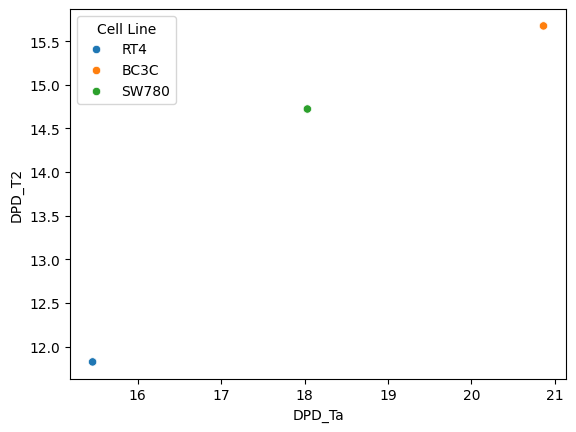

In [74]:
sns.scatterplot(
    data=DPD_df.loc[['ACH-000242', 'ACH-000593', 'ACH-000384']],
    x='DPD_Ta',
    y='DPD_T2',
    hue='Cell Line'
)